# Sensor Data Warehouse — storage & retrieval

A **data-storage** project: design a normalised schema for high-volume IoT sensor
readings, bulk-load it efficiently, and show *why* the storage decisions matter.

Built by [`src/build_store.py`](../src/build_store.py) from the DDL in
[`schema.sql`](../schema.sql): 4 locations × 3 sensor types × 90 days of hourly
readings ≈ **26k measurements**.

**Covered:** normalised schema design, bulk loading in a transaction, the impact of
**indexing**, time-series retrieval/aggregation in SQL, and a **storage-format
comparison** (CSV vs SQLite vs Parquet) on size and read speed.


In [1]:
import sqlite3, time, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
conn = sqlite3.connect("../data/sensors.db")

# row counts per table
for t in ["locations", "sensors", "readings"]:
    n = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:>10}: {n:,} rows")

 locations: 4 rows
   sensors: 12 rows
  readings: 25,920 rows


## 1. The schema

Reference data (`locations`, `sensors`) is kept out of the high-volume fact table
(`readings`) — the fact table stays narrow and typed, so writes are cheap and we never
repeat city names or units per row. A foreign key links each reading to its sensor.

In [2]:
print(pd.read_sql_query("SELECT * FROM locations", conn).to_string(index=False))
print()
print(pd.read_sql_query("SELECT * FROM sensors LIMIT 6", conn).to_string(index=False))

 location_id             name     city  latitude  longitude
           1   Leuven Station   Leuven    50.879      4.700
           2 Brussels Station Brussels    50.851      4.357
           3    Ghent Station    Ghent    51.054      3.717
           4  Antwerp Station  Antwerp    51.219      4.402

 sensor_id  location_id sensor_type  unit installed_on
         1            1 temperature     C   2024-01-01
         2            1    humidity     %   2024-01-01
         3            1        pm25 ug/m3   2024-01-01
         4            2 temperature     C   2024-01-01
         5            2    humidity     %   2024-01-01
         6            2        pm25 ug/m3   2024-01-01


## 2. A typical retrieval — joins across the schema

In [3]:
q = '''
SELECT l.city, s.sensor_type, s.unit,
       COUNT(*)            AS n,
       ROUND(AVG(r.value),2) AS avg_value,
       ROUND(MIN(r.value),2) AS min_value,
       ROUND(MAX(r.value),2) AS max_value
FROM readings r
JOIN sensors  s ON s.sensor_id   = r.sensor_id
JOIN locations l ON l.location_id = s.location_id
GROUP BY l.city, s.sensor_type, s.unit
ORDER BY l.city, s.sensor_type
'''
pd.read_sql_query(q, conn).head(12)

,city,sensor_type,unit,n,avg_value,min_value,max_value
0,Antwerp,humidity,%,2160,70.06,50.33,89.04
1,Antwerp,pm25,ug/m3,2160,18.08,2.38,31.04
2,Antwerp,temperature,C,2160,11.89,1.33,21.29
3,Brussels,humidity,%,2160,70.05,46.54,87.65
4,Brussels,pm25,ug/m3,2160,18.02,4.43,31.21
5,Brussels,temperature,C,2160,12.03,0.16,23.22
6,Ghent,humidity,%,2160,70.00,50.88,93.88
7,Ghent,pm25,ug/m3,2160,18.04,4.63,34.53
8,Ghent,temperature,C,2160,12.00,1.54,22.23
9,Leuven,humidity,%,2160,70.13,48.52,91.75


## 3. Why the index matters

The composite index `(sensor_id, ts)` targets the dominant access pattern: *one
sensor's readings over a time window*. To show its effect we load the readings into
an **in-memory** database and time the same query before and after indexing.

In [4]:
readings = pd.read_sql_query("SELECT * FROM readings", conn)

mem = sqlite3.connect(":memory:")
readings.to_sql("readings", mem, index=False)

query = '''SELECT AVG(value) FROM readings
           WHERE sensor_id = 5 AND ts BETWEEN '2024-05-01' AND '2024-05-15' '''

def timeit(c, q, n=200):
    t0 = time.perf_counter()
    for _ in range(n):
        c.execute(q).fetchall()
    return (time.perf_counter() - t0) / n * 1000   # ms/query

no_idx = timeit(mem, query)
print("Plan WITHOUT index:")
for r in mem.execute("EXPLAIN QUERY PLAN " + query):
    print("  ", r[-1])

mem.execute("CREATE INDEX idx_sensor_ts ON readings(sensor_id, ts)")
mem.execute("ANALYZE")
with_idx = timeit(mem, query)
print("\nPlan WITH index:")
for r in mem.execute("EXPLAIN QUERY PLAN " + query):
    print("  ", r[-1])

print(f"\nNo index : {no_idx:.3f} ms/query")
print(f"Indexed  : {with_idx:.3f} ms/query")
print(f"Speed-up : {no_idx / with_idx:.1f}x")

Plan WITHOUT index:
   SCAN readings

Plan WITH index:
   SEARCH readings USING INDEX idx_sensor_ts (sensor_id=? AND ts>? AND ts<?)

No index : 1.346 ms/query
Indexed  : 0.068 ms/query
Speed-up : 19.9x


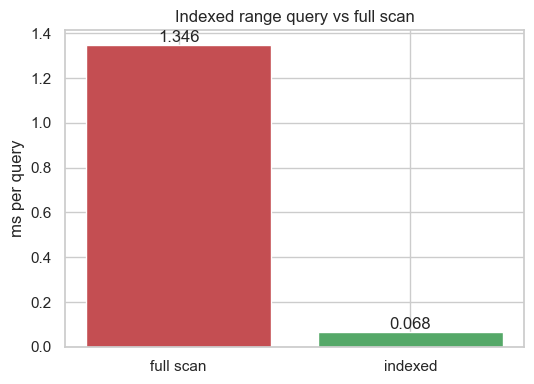

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(["full scan", "indexed"], [no_idx, with_idx],
       color=["#C44E52", "#55A868"])
ax.set_ylabel("ms per query"); ax.set_title("Indexed range query vs full scan")
for i, v in enumerate([no_idx, with_idx]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 4. Time-series aggregation — daily averages

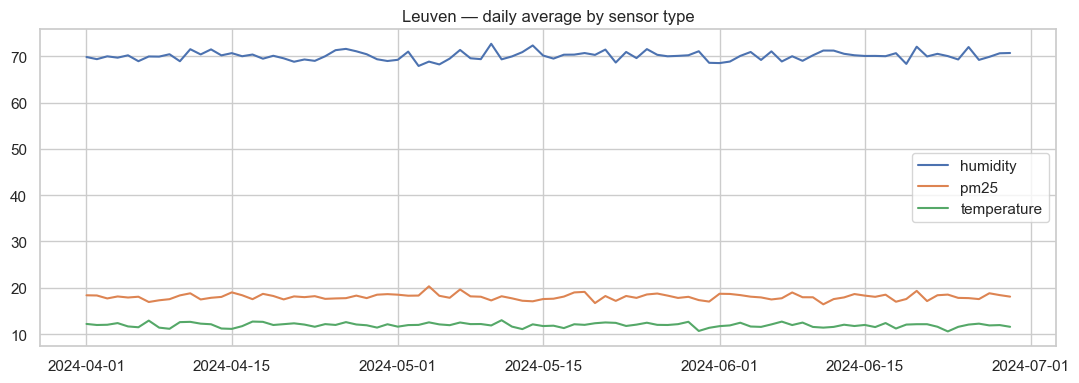

In [6]:
ts = pd.read_sql_query('''
    SELECT substr(r.ts, 1, 10) AS day,
           s.sensor_type,
           ROUND(AVG(r.value), 2) AS avg_value
    FROM readings r
    JOIN sensors s ON s.sensor_id = r.sensor_id
    JOIN locations l ON l.location_id = s.location_id
    WHERE l.city = 'Leuven'
    GROUP BY day, s.sensor_type
    ORDER BY day
''', conn)
ts["day"] = pd.to_datetime(ts["day"])

fig, ax = plt.subplots(figsize=(11, 4))
for stype, g in ts.groupby("sensor_type"):
    ax.plot(g["day"], g["avg_value"], label=stype)
ax.set_title("Leuven — daily average by sensor type"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Storage-format comparison

The same 26k-row fact table stored three ways. Row stores (CSV, SQLite) vs the
columnar, compressed **Parquet** format — comparing file size and full-scan read time.

,size_KB,full_read_ms
CSV,850.72,9.07
SQLite,1840.00,44.66
Parquet,230.10,8.12


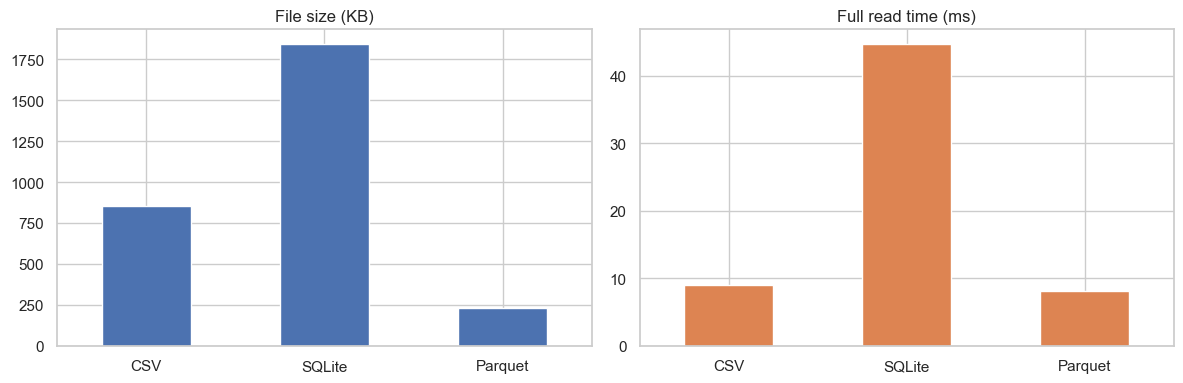

In [7]:
readings.to_csv("../data/readings.csv", index=False)

files = {
    "CSV":     "../data/readings.csv",
    "SQLite":  "../data/sensors.db",       # whole db (mostly the readings table)
    "Parquet": "../data/readings.parquet",
}
sizes = {k: os.path.getsize(v) / 1024 for k, v in files.items()}  # KB

def read_time(kind, path, n=20):
    t0 = time.perf_counter()
    for _ in range(n):
        if kind == "CSV":
            pd.read_csv(path)
        elif kind == "Parquet":
            pd.read_parquet(path)
        else:
            cc = sqlite3.connect(path)
            pd.read_sql_query("SELECT * FROM readings", cc); cc.close()
    return (time.perf_counter() - t0) / n * 1000  # ms

read_ms = {k: read_time(k, v) for k, v in files.items()}

comp = pd.DataFrame({"size_KB": sizes, "full_read_ms": read_ms}).round(2)
display(comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comp["size_KB"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("File size (KB)"); axes[0].tick_params(axis="x", rotation=0)
comp["full_read_ms"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Full read time (ms)"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

In [8]:
conn.close()

## Takeaways

* **Normalisation** keeps the fact table narrow; reference data lives in small tables
  joined on foreign keys.
* A **composite index** on the dominant `(sensor_id, ts)` access pattern turns a full
  scan into an index range scan — a large speed-up that grows with table size.
* **Storage format is a real trade-off:** SQLite gives indexed point/range queries;
  **Parquet** is far smaller and fastest for full-table analytical scans. Pick per
  workload — often *both* (operational DB + columnar export for analytics).

**Extensions:** partition Parquet by day/sensor, add retention/rollup tables for
downsampled history, and benchmark against DuckDB for analytical queries.